# Autogen API Overview

- This notebook shows the working of autogen API and all its individual components and its explanations.

In [3]:
import asyncio
import os
import io
import requests
import PIL.Image
import IPython.display
import autogen_core
import autogen_agentchat
import autogen_agentchat.teams as teams
import autogen_ext.models.openai as openai  # For OpenAIChatCompletionClient
import autogen_agentchat.agents as agent    # For AssistantAgent
import autogen_agentchat.messages as msg     # For Message and Event types
import autogen_agentchat.base as base        # For TaskResult
import autogen_agentchat.ui as ui
from autogen_core.models import UserMessage
import autogen_core.tools as tools #FunctionTool
import autogen_utils
import autogen_ext.code_executors.local as code_exec 
import autogen_agentchat.conditions as conditions


## Agents

### Assistant Agent
- AssistantAgent is a built-in agent that uses a language model and has the ability to use tools.
- The below cell shows how to implement the agent

In [4]:
async def web_search(query: str) -> str:
    """Find information on the web"""
    return "AutoGen is a programming framework for building multi-agent applications."


# Create an agent that uses the OpenAI GPT-4o model.
model_client = openai.OpenAIChatCompletionClient(
    model="gpt-4.1-nano",
    api_key="YOUR_API_KEY", 
)
autogen_agentchat = agent.AssistantAgent(
    name="assistant",
    model_client=model_client,
    tools=[web_search],
    system_message="Use tools to solve tasks.",
)

The 2 **cells below** sends a user message to the OpenAI model client and prints the model’s response.

In [23]:
result = await agent.run(task="Find information on AutoGen")
print(result.messages[-1].content)

AutoGen is a programming framework that is designed to facilitate the development of multi-agent applications. It provides tools and structures to create, manage, and coordinate multiple autonomous agents working together to achieve complex tasks. AutoGen is often used in contexts where systems require collaboration between different agents, such as in artificial intelligence, automation, and complex system simulations.

If you need more detailed information about its features, use cases, or how to get started with AutoGen, please specify!


In [24]:
result = await openai_model_client.create([UserMessage(content="What is the capital of France?", source="user")])
print(result)

finish_reason='stop' content='The capital of France is Paris.' usage=RequestUsage(prompt_tokens=15, completion_tokens=7) cached=False logprobs=None thought=None


### Multi-Modal Input
- The AssistantAgent can handle multi-modal input by providing the input as a MultiModalMessage as shown below


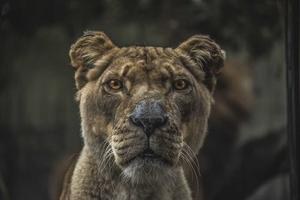

In [37]:
# Create a multi-modal message with random image and text.
pil_image = PIL.Image.open(io.BytesIO(requests.get("https://picsum.photos/300/200").content))
img = autogen_core.Image(pil_image)
multi_modal_message = msg.MultiModalMessage(content=["Can you describe the content of this image?", img], source="user")
img


### Streaming Messages
- Streaming each message can be done using the `run_stream()` method and use Console to print the messages as they appear to the console as shown in the below cell.

In [36]:
async def assistant_run_stream() -> None:
    # Option 1: read each message from the stream (as shown in the previous example).
    # async for message in agent.run_stream(task="Find information on AutoGen"):
    #     print(message)

    # Option 2: use Console to print all messages as they appear.
    await ui.Console(
        autogen_agentchat.run_stream(task="Find information on AutoGen"),
        output_stats=True,  # Enable stats printing.
    )


# Use asyncio.run(assistant_run_stream()) when running in a script.
await assistant_run_stream()

---------- TextMessage (user) ----------
Find information on AutoGen
---------- ToolCallRequestEvent (assistant) ----------
[FunctionCall(id='call_Rkf4nDi6rBCQZhrUPXaYapmJ', arguments='{"query":"AutoGen"}', name='web_search')]
[Prompt tokens: 61, Completion tokens: 15]
---------- ToolCallExecutionEvent (assistant) ----------
[FunctionExecutionResult(content='AutoGen is a programming framework for building multi-agent applications.', name='web_search', call_id='call_Rkf4nDi6rBCQZhrUPXaYapmJ', is_error=False)]
---------- ToolCallSummaryMessage (assistant) ----------
AutoGen is a programming framework for building multi-agent applications.
---------- Summary ----------
Number of messages: 4
Finish reason: None
Total prompt tokens: 61
Total completion tokens: 15
Duration: 6.13 seconds


### Function Tool
- The web_search_func tool is an example of a function tool. The schema is automatically generated.
- The cell below shows its working

In [41]:
# Define a tool using a Python function.
async def web_search_func(query: str) -> str:
    """Find information on the web"""
    return "AutoGen is a programming framework for building multi-agent applications."


# This step is automatically performed inside the AssistantAgent if the tool is a Python function.
web_search_function_tool = tools.FunctionTool(web_search_func, description="Find information on the web")
# The schema is provided to the model during AssistantAgent's on_messages call.
web_search_function_tool.schema

{'name': 'web_search_func',
 'description': 'Find information on the web',
 'parameters': {'type': 'object',
  'properties': {'query': {'description': 'query',
    'title': 'Query',
    'type': 'string'}},
  'required': ['query'],
  'additionalProperties': False},
 'strict': False}

### Parallel Tool Calls
Some models can call multiple tools simultaneously. By default, `AssistantAgent` executes parallel tool calls if the model client produces them.

> **Caution:** Disable parallel tool calls when tools have side effects or when consistent agent behavior is required. This is configured at the model client level.

**Important:**  
- `AgentTool` and `TeamTool` **must not** run in parallel due to internal state conflicts.  
- For `OpenAIChatCompletionClient` and `AzureOpenAIChatCompletionClient`, set `parallel_tool_calls=False` to disable parallel execution.

In [42]:
model_client_no_parallel_tool_call = openai.OpenAIChatCompletionClient(
    model="gpt-4o",
    parallel_tool_calls=False,  # type: ignore
)
agent_no_parallel_tool_call = agent.AssistantAgent(
    name="assistant",
    model_client=model_client_no_parallel_tool_call,
    tools=[web_search],
    system_message="Use tools to solve tasks.",
)

### Tool Iterations
- One model call followed by one tool call or parallel tool calls is a single tool iteration. By default, the AssistantAgent will execute at most one iteration.

In [44]:
agent_loop = agent.AssistantAgent(
    name="assistant_loop",
    model_client=model_client_no_parallel_tool_call,
    tools=[web_search],
    system_message="Use tools to solve tasks.",
    max_tool_iterations=10,  # At most 10 iterations of tool calls before stopping the loop.
)

### Streaming Tokens
- You can stream the tokens generated by the model client by setting model_client_stream=True. This will cause the agent to yield ModelClientStreamingChunkEvent messages in run_stream() as shown in the below cell.
- You can see the streaming chunks in the output above. The chunks are generated by the model client and are yielded by the agent as they are received. The final response, the concatenation of all the chunks, is yielded right after the last chunk in the output in the cell below

In [53]:

streaming_assistant = agent.AssistantAgent(
    name="assistant",
    model_client=model_client,
    system_message="You are a helpful assistant.",
    model_client_stream=True,  # Enable streaming tokens.
)

# Use an async function and asyncio.run() in a script.
async for message in streaming_assistant.run_stream(task="Name two cities in South America"):  # type: ignore
    print(message)

id='7f4a3ea7-f5f1-4774-94a4-dd34a60ed685' source='user' models_usage=None metadata={} created_at=datetime.datetime(2026, 2, 18, 17, 4, 44, 93505, tzinfo=datetime.timezone.utc) content='Name two cities in South America' type='TextMessage'
id='3908181c-edaf-413c-9220-7a0a3588f9ec' source='assistant' models_usage=None metadata={} created_at=datetime.datetime(2026, 2, 18, 17, 4, 44, 909406, tzinfo=datetime.timezone.utc) content='Sure' full_message_id='7d338e89-13ba-4365-8a38-964ce5b04be9' type='ModelClientStreamingChunkEvent'
id='4e8411b8-f3aa-4f4d-938a-b94a99c9a891' source='assistant' models_usage=None metadata={} created_at=datetime.datetime(2026, 2, 18, 17, 4, 44, 910162, tzinfo=datetime.timezone.utc) content='!' full_message_id='7d338e89-13ba-4365-8a38-964ce5b04be9' type='ModelClientStreamingChunkEvent'
id='8820c08a-3b5a-4d1f-a457-f930e5a3598a' source='assistant' models_usage=None metadata={} created_at=datetime.datetime(2026, 2, 18, 17, 4, 44, 911728, tzinfo=datetime.timezone.utc) con

## Messages
There are primarily 2 types of messages in autogen:
- Agent-Agent Messages
- Agent's Internal Events

### The Below cell shows the working of Agent to Agent communication

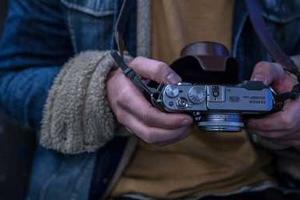


--- Message from User ---
['Look at this camera feed and discuss it.', <autogen_core._image.Image object at 0x780f00ab8800>]

--- Message from Vision_Specialist ---
The image shows a person holding a camera. The camera is an older or retro-style model with manual controls visible, such as dials and switches. The person is wearing a denim jacket with a shearling lining and a beige or brown inner layer, suggesting colder weather. The focus is on the camera and the person's hands, emphasizing the act of handling or adjusting the camera settings. The overall mood is casual and perhaps indicative of someone preparing to take a photograph.

--- Message from Reviewer ---
The image captures someone adjusting or preparing to use a retro-style camera, evident by the manual controls like dials and switches. Their attire—a denim jacket with shearling lining—suggests a cooler environment. The focus on the hands and camera highlights the technical engagement and casual mood, hinting at an interest 

In [6]:
# 1. Setup the Model Client (using existing openai_model_client from previous step)

# 2. Define Agent A: The Vision Specialist
vision_agent = autogen_agentchat.agents.AssistantAgent(
    name="Vision_Specialist",
    model_client=openai_model_client,
    system_message="Describe the image provided in detail."
)

# 3. Define Agent B: The Reviewer
reviewer_agent = autogen_agentchat.agents.AssistantAgent(
    name="Reviewer",
    model_client=openai_model_client,
    system_message="Based on the description provided, suggest one creative use for this item."
)

# 4. Create the Team (This enables true Agent-to-Agent communication)
agent_team = autogen_agentchat.teams.RoundRobinGroupChat(
    [vision_agent, reviewer_agent],
    max_turns=2
)

# 5. Prepare the MultiModalMessage from your local file
pil_image = PIL.Image.open("camera.png")
img = autogen_core.Image(pil_image)
IPython.display.display(pil_image)

input_message = autogen_agentchat.messages.MultiModalMessage(
    content=["Look at this camera feed and discuss it.", img],
    source="User"
)

# 6. Run the Team
# The team will pass the MultiModalMessage from the User to Agent A, 
# then Agent A's response to Agent B automatically.
async for message in agent_team.run_stream(task=input_message):
    # TaskResult objects don't have 'source', so we check if 'source' exists
    if hasattr(message, "source"):
        print(f"\n--- Message from {message.source} ---")
        print(message.content)
    else:
        # This handles the final TaskResult object
        print("\n--- Task Complete ---")
        # Optional: print(message.stop_reason)

### Agent's Internal Events
- In the below example, the agent does not show reasoning because the question is a simple factual lookup, and the model directly produces the answer without generating visible step-by-step reasoning.

In [8]:
async def internal_events():
    # 1. Setup the client using the 'openai' alias

    # 2. Setup the agent using the 'agent' alias
    # model_client_stream=True is required to see the internal 'Thinking' events
    solo_agent = agent.AssistantAgent(
        name="Solo_Assistant",
        model_client=openai_model_client,
        system_message="You are a helpful assistant.",
        model_client_stream=True 
    )

    print("--- Execution Started ---\n")

    # 3. Process the stream using the 'msg' and 'base' aliases
    async for event in solo_agent.run_stream(task="What is the capital of France?"):
        
        # Internal "Live" Streaming (Individual tokens as they arrive)
        if isinstance(event, msg.ModelClientStreamingChunkEvent):
            if event.content:
                print(event.content, end="", flush=True)

        # Final Messages (Completed response blocks)
        # We check specific types to avoid the generic ChatMessage TypeError
        elif isinstance(event, (msg.TextMessage, msg.MultiModalMessage, msg.StopMessage)):
            # Filter out the 'user' prompt to keep the output clean
            if event.source != "user":
                print(f"\n\n[FINAL MESSAGE from {event.source}]:")
                print(event.content)

        # Final Summary using the 'base' alias
        elif isinstance(event, base.TaskResult):
            print(f"\n\n--- Task Finished | Reason: {event.stop_reason} ---")

# Run the block
await internal_events()

--- Execution Started ---

The capital of France is Paris.

[FINAL MESSAGE from Solo_Assistant]:
The capital of France is Paris.


--- Task Finished | Reason: None ---


## Teams
AgentChat supports several team presets:
- RoundRobinGroupChat: A team that runs a group chat with participants taking turns in a round-robin fashion (covered on this page). 
- SelectorGroupChat: A team that selects the next speaker using a ChatCompletion model after each message. 
- MagenticOneGroupChat: A generalist multi-agent system for solving open-ended web and file-based tasks across a variety of domains. 
- Swarm: A team that uses HandoffMessage to signal transitions between agents.

The demonstration will primarily highlight `SelectorGroupChat`, as it is the key element in the `autogen.example.ipynb example`.

In [6]:
# Analyst system message (no TERMINATE here)
analyst = agent.AssistantAgent(
    name="Analyst",
    model_client=model_client,
    system_message="""
You are a Senior Quantitative Analyst.
Answer clearly and concisely.
"""
)

# Reviewer system message
reviewer = agent.AssistantAgent(
    name="Reviewer",
    model_client=model_client,
    system_message="""
You are a peer reviewer.
Comment on the Analyst's output briefly.
"""
)

# Team termination condition
termination_condition = conditions.TextMentionTermination("TERMINATE")  # you can instead use a timeout or max_turns
team = teams.SelectorGroupChat(
    [analyst, reviewer],
    model_client=model_client,
    termination_condition=termination_condition, 
    max_turns=6
)

### Observing a Team
- Similar to the agent’s `on_messages_stream()` method, you can stream the team’s messages while it is running by calling the `run_stream()` method. This method returns a generator that yields messages produced by the agents in the team as they are generated, with the final item being the TaskResult object.



In [7]:
# Task prompt
task_prompt = "Summarize the hypothetical company 'ExampleCorp' in 2 sentences. Provide one key insight."

# Run
async for message in team.run_stream(task=task_prompt):
    if hasattr(message, "source") and isinstance(message.content, str):
        print(f"{message.source}: {message.content.strip()}\n")
    elif hasattr(message, "stop_reason"):
        print(f"🏁 Mission Complete: {message.stop_reason}\n")


user: Summarize the hypothetical company 'ExampleCorp' in 2 sentences. Provide one key insight.

Analyst: ExampleCorp is a technology-driven company specializing in cloud computing and enterprise software solutions, with a rapidly expanding customer base and significant revenue growth in recent years. A key insight is that despite strong growth, the company faces increasing competition and margin pressures, emphasizing the need for continued innovation and operational efficiency.

Reviewer: The summary effectively highlights ExampleCorp’s core business focus and recent growth trajectory. The key insight about rising competition and margin pressures provides a valuable strategic perspective, though elaborating on specific competitive challenges or innovative strategies could enhance the analysis.

Analyst: Thank you for your feedback. I will consider including more specific details on competitive challenges and innovative strategies to provide a deeper strategic context.

Reviewer: You'

## Human in the Loop

There are two main ways to interact with the team from your application:
- During a team’s run – execution of `run()` or `run_stream()`, provide feedback through a UserProxyAgent.
- Once the run terminates, provide feedback through input to the next call to `run()` or `run_stream()`.